# Descriptive statistics of microbial data

In this notebook we will explore the characteristics of microbial data further.

# Clone Github Repo

Start by cloning our repo to be able to store our data orderly

In [15]:
# 1. Clone GitHub repo to Colab (run only once or restart session!)
REPO_URL = "https://github.com/hector-ahg/predictive-microbiology-course.git"

!git clone $REPO_URL


Cloning into 'predictive-microbiology-course'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 261 (delta 73), reused 66 (delta 27), pack-reused 141 (from 1)
Receiving objects: 100% (261/261), 123.60 MiB | 33.28 MiB/s, done.
Resolving deltas: 100% (109/109), done.


In [16]:
%cd predictive-microbiology-course

/content/predictive-microbiology-course/predictive-microbiology-course


# Mount drive


In [17]:
from google.colab import drive
from pathlib import Path
import shutil
import os
# Drive folder name

# Toggle Drive export
SAVE_TO_DRIVE = True

# Drive folder name
drive_folder = "RESULTS_FROM_QIIME2_PICRUST2_IN_COLAB"

def mount_drive():

    drive.mount(
        "/content/driveDL",
        force_remount=True
    )

    project_root_drive = Path(
        f"/content/driveDL/MyDrive/{drive_folder}"
    )

    project_root_drive.mkdir(
        parents=True,
        exist_ok=True
    )

    return project_root_drive

results_in_drive = mount_drive()



Mounted at /content/driveDL


In [18]:
results_in_drive = mount_drive()


Mounted at /content/driveDL


# Load packages

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, dendrogram
import io


sns.set(style="whitegrid")
%matplotlib inline

# Paths

In [55]:
# Paths


BASE_DIR = Path("/content/predictive-microbiology-course").resolve() #project_root
print("Current working directory:", BASE_DIR)

BASE_DIR_GOOGLE = Path("/content/driveDL/MyDrive/RESULTS_FROM_QIIME2_PICRUST2_IN_COLAB").resolve() #project_root
print("Current working directory:", BASE_DIR_GOOGLE)

DATA_DIR = (BASE_DIR / "dataset").resolve()
DATA_IBDMDB = (DATA_DIR /"ibdmdb_hmp2").resolve()
PATH_results = (BASE_DIR_GOOGLE / "results").resolve()


# DADA2
DADA2_RESULT_DIR = (PATH_results / "dada2_trunc_180").resolve()
taxa_file = DADA2_RESULT_DIR / "taxa_export" /  "taxonomy.tsv"
feature_file = DADA2_RESULT_DIR / "table_export" /  "feature-table.tsv"

# PICRUST2
PICRUST2_RESULT_DIR = (PATH_results / "picrust2_out2").resolve()
ec_file = PICRUST2_RESULT_DIR / "EC_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
#ko_file = PICRUST2_RESULT_DIR / "KO_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
#pathways_contrib_file = PICRUST2_RESULT_DIR / "pathways_out" / "path_abun_contrib.tsv.gz"
pathways_unstrat_file = PICRUST2_RESULT_DIR / "pathways_out" / "path_abun_unstrat.tsv.gz"


# Create figures directory
FIG_PATH = BASE_DIR_GOOGLE / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

# Create tables directory
TABLE_PATH = PATH_results / "results_tables"
TABLE_PATH.mkdir(parents=True, exist_ok=True)

# Metadata
metadata_file = DATA_DIR / "ibdmdb_hmp2"/ "metadata" / "hmp2_metadata_2018-08-20_fixed.tsv" # "metadata.tsv"


Current working directory: /content/predictive-microbiology-course
Current working directory: /content/driveDL/MyDrive/RESULTS_FROM_QIIME2_PICRUST2_IN_COLAB


# Taxonomic composition analysis with data from QIIME2

## Features table (ASVs)

In [22]:
# Load taxa data
features = pd.read_csv(feature_file, sep="\t", skiprows=1, index_col=0)
features.index.name = "FeatureID" # Set index name to "FeatureID" for clarity

# Check, rows = ASVs, columns = samples
features.head()

,206534,206536,206538,206547,206548,206561,206562,206563,206564,206569,...,222171,224323,224324,224325,224326,224327,224328,224330,224844,224845
FeatureID,,,,,,,,,,,,,,,,,,,,,
99deb3c5ecb022ec05609ebd1112a557,11.0,13.0,5.0,6.0,19.0,1788.0,3373.0,3325.0,646.0,4996.0,...,0.0,8250.0,13007.0,6735.0,6015.0,11140.0,12297.0,18163.0,1739.0,6736.0
f5f5e0da89730462abaf6301a9557193,486.0,513.0,160.0,0.0,0.0,756.0,2571.0,4581.0,769.0,743.0,...,850.0,5484.0,4063.0,1383.0,1761.0,6156.0,6120.0,2718.0,4743.0,9431.0
2c982937754e6321f861027032db80f7,12105.0,10525.0,4613.0,0.0,0.0,35.0,93.0,463.0,103.0,37.0,...,0.0,52.0,0.0,0.0,11.0,6656.0,8679.0,0.0,0.0,0.0
d46e2205f0c6ecf67b51f83d111c509c,1564.0,1683.0,821.0,7272.0,2664.0,26.0,44.0,22.0,141.0,2.0,...,35.0,1957.0,2544.0,2360.0,2534.0,4832.0,4087.0,101.0,561.0,309.0
8e175abe6a746b8f33bae9cd7c8192bb,0.0,0.0,0.0,5.0,0.0,175.0,457.0,452.0,98.0,216.0,...,528.0,34.0,36.0,2173.0,2442.0,473.0,314.0,13.0,448.0,1054.0


## Taxonomy table

In [23]:
# Load taxa data
taxa = pd.read_csv(taxa_file, sep="\t", index_col=0)
taxa.index.name = "FeatureID" # Set index name to "FeatureID" for clarity

taxa.head()

,Taxon,Confidence
FeatureID,,
99deb3c5ecb022ec05609ebd1112a557,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,0.999986
f5f5e0da89730462abaf6301a9557193,d__Bacteria;p__Firmicutes;c__Clostridia;o__Osc...,0.988007
2c982937754e6321f861027032db80f7,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,0.999979
d46e2205f0c6ecf67b51f83d111c509c,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.908343
8e175abe6a746b8f33bae9cd7c8192bb,d__Bacteria;p__Firmicutes;c__Clostridia;o__Osc...,0.995147


In [24]:
taxa['Taxon'].tolist()[:20]

['d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__',
 'd__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium;s__',
 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__',
 'd__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Escherichia-Shigella;s__',
 'd__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium;s__',
 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__',
 'd__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium;s__',
 'd__Bacteria;p__Firmicutes;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__[Ruminococcus]_torques_group;s__',
 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__',
 'd__Bacteria;p__Firmicutes;c__Clo

In [25]:
# Taxonomy parsing (GENUS level)
def extract_tax_level(tax_lineage, prefix):
    if pd.isna(tax_lineage):
        return "Unclassified"

    for level in str(tax_lineage).split(";"):
        level = level.strip()  # remove spaces

        if level.startswith(prefix):
            value = level.replace(prefix, "").strip()

            if value == "" or value == "_":
                return "Unclassified"

            return value

    return "Unclassified"



In [26]:
taxa["Taxon_clean"] = (
    taxa["Taxon"]
    .astype(str)
    .str.replace(r"\s+", "", regex=True)  # remove ALL spaces
)

taxa["Genus"] = taxa["Taxon_clean"].apply(lambda x: extract_tax_level(x, "g__")) # Extract genus level taxonomy
taxa["Genus"]

,Genus
FeatureID,
99deb3c5ecb022ec05609ebd1112a557,Bacteroides
f5f5e0da89730462abaf6301a9557193,Faecalibacterium
2c982937754e6321f861027032db80f7,Bacteroides
d46e2205f0c6ecf67b51f83d111c509c,Escherichia-Shigella
8e175abe6a746b8f33bae9cd7c8192bb,Faecalibacterium
...,...
b42f09297bd4780da27b6da502847ebe,Roseburia
1de4896460562cae3be7c9d14bfe84cf,Unclassified
d88bda45070b62e20c417b1ec04eabaa,Christensenellaceae_R-7_group


## Merge taxonomy with ASVs

In [27]:
features['FeatureID'] = features.index # Ensure 'FeatureID' is a column for merging

df_merged = features.join(taxa["Genus"])

In [28]:
df_merged.head()

,206534,206536,206538,206547,206548,206561,206562,206563,206564,206569,...,224324,224325,224326,224327,224328,224330,224844,224845,FeatureID,Genus
FeatureID,,,,,,,,,,,,,,,,,,,,,
99deb3c5ecb022ec05609ebd1112a557,11.0,13.0,5.0,6.0,19.0,1788.0,3373.0,3325.0,646.0,4996.0,...,13007.0,6735.0,6015.0,11140.0,12297.0,18163.0,1739.0,6736.0,99deb3c5ecb022ec05609ebd1112a557,Bacteroides
f5f5e0da89730462abaf6301a9557193,486.0,513.0,160.0,0.0,0.0,756.0,2571.0,4581.0,769.0,743.0,...,4063.0,1383.0,1761.0,6156.0,6120.0,2718.0,4743.0,9431.0,f5f5e0da89730462abaf6301a9557193,Faecalibacterium
2c982937754e6321f861027032db80f7,12105.0,10525.0,4613.0,0.0,0.0,35.0,93.0,463.0,103.0,37.0,...,0.0,0.0,11.0,6656.0,8679.0,0.0,0.0,0.0,2c982937754e6321f861027032db80f7,Bacteroides
d46e2205f0c6ecf67b51f83d111c509c,1564.0,1683.0,821.0,7272.0,2664.0,26.0,44.0,22.0,141.0,2.0,...,2544.0,2360.0,2534.0,4832.0,4087.0,101.0,561.0,309.0,d46e2205f0c6ecf67b51f83d111c509c,Escherichia-Shigella
8e175abe6a746b8f33bae9cd7c8192bb,0.0,0.0,0.0,5.0,0.0,175.0,457.0,452.0,98.0,216.0,...,36.0,2173.0,2442.0,473.0,314.0,13.0,448.0,1054.0,8e175abe6a746b8f33bae9cd7c8192bb,Faecalibacterium


In [29]:
# Aggregate
genus_table = df_merged.groupby("Genus").sum()

In [30]:
genus_table.drop(columns=["FeatureID"], inplace=True) # Remove 'FeatureID' column after aggregation
genus_table.head()

,206534,206536,206538,206547,206548,206561,206562,206563,206564,206569,...,222171,224323,224324,224325,224326,224327,224328,224330,224844,224845
Genus,,,,,,,,,,,,,,,,,,,,,
AKIW781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AKYH767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Abiotrophia,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0
Acetanaerobacterium,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
Acidaminococcus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
TABLE_PATH

PosixPath('/content/driveDL/MyDrive/RESULTS_FROM_QIIME2_PICRUST2_IN_COLAB/results_tables')

In [34]:
# Normalize to relative abundance
genus_rel = genus_table.div(genus_table.sum(axis=0), axis=1)

genus_rel.to_csv(TABLE_PATH / "genus_relative_abundance.csv")

# select top genera
top_n = 10
top_genera = genus_rel.mean(axis=1).sort_values(ascending=False).head(top_n).index

genus_top = genus_rel.loc[top_genera]

# Compute "Other"
other = genus_rel.drop(index=top_genera).sum()
genus_top.loc["Other"] = other

# Transpose
plot_data = genus_top.T

## Dendogram

Hierarchical clustering of samples. Each sample is a composition vector consisting of top genra +  "other" category. Values are relative abundances. It shows how different  two samples in their full genus composition are, according to Euclidean distance. It repeatedly merges samples/clusters that minimize the increase in total within-cluster variance. Thus, groups samples that have similar genus compositions.

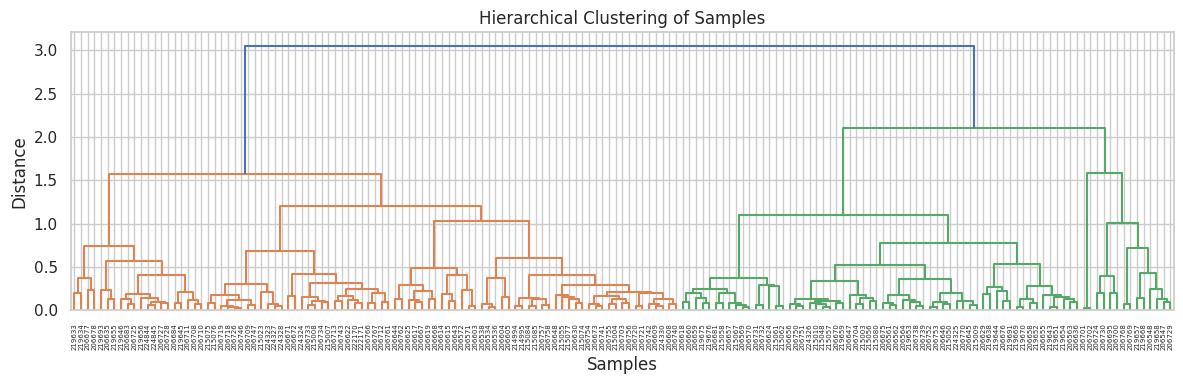

In [35]:

plt.figure(figsize=(12, 4))

Z = linkage(plot_data, method='ward', metric='euclidean')

dendrogram(
    Z,
    labels=plot_data.index,  # sample names
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Samples")
plt.ylabel("Distance")
plt.xlabel("Samples")

plt.tight_layout()
plt.show()

## Barplot taxa QIIME2

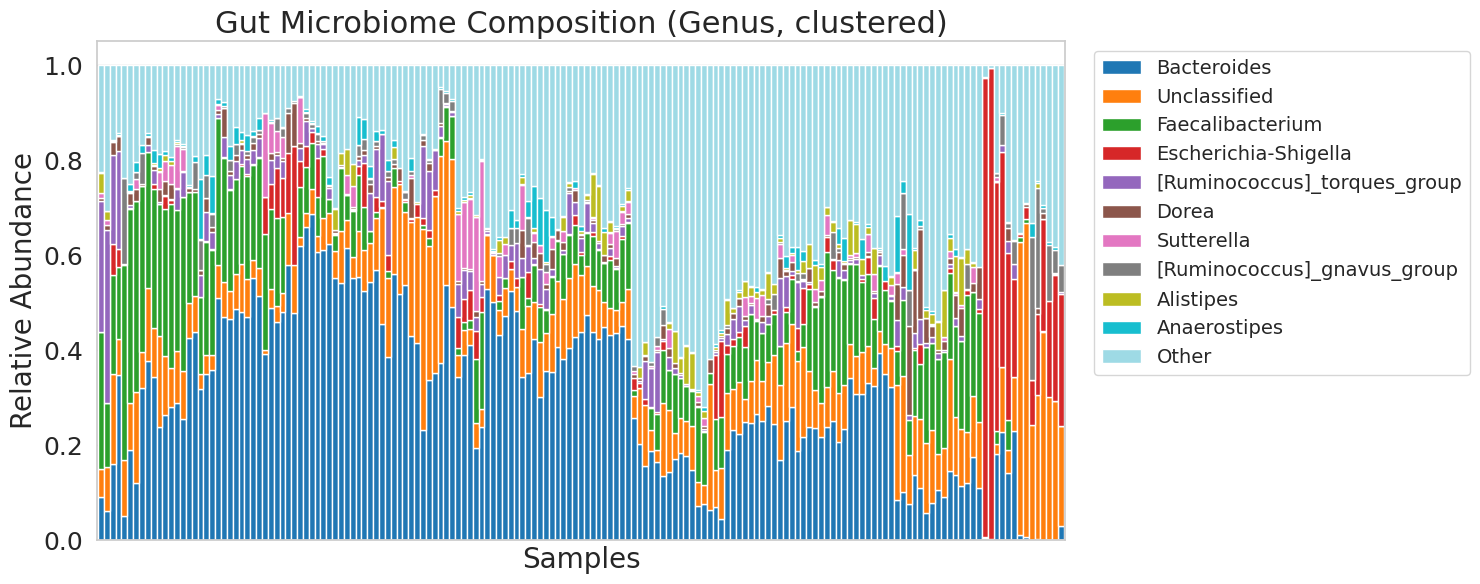

In [36]:

# Cluster samples
Z = linkage(plot_data, method='ward') # Compute hierarchical clustering using euclidean distance and Ward's method

# Get sample order
idx = dendrogram(Z, no_plot=True)['leaves'] # Get the order of samples from the dendrogram

# Reorder samples
df_plot_sorted = plot_data.iloc[idx]

n = len(df_plot_sorted.columns)

colors = plt.cm.tab20(np.linspace(0, 1, n))  # enough distinct colors

df_plot_sorted.plot(
    kind='bar',
    stacked=True,
    width=1.0,
    color=colors,
    figsize=(15, 6)
)

plt.xlabel("Samples", fontsize=20)
plt.ylabel("Relative Abundance", fontsize=20)
plt.title("Gut Microbiome Composition (Genus, clustered)", fontsize=22)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=18)
plt.xticks([])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)

plt.tight_layout()
plt.savefig(FIG_PATH / "genus_composition_qiime2.png", dpi=300, bbox_inches='tight')
plt.show()

## Alpha diversity

We already explored alpha diversity plots during the theory session. However, we may want to produce publication-level plots. Here, we plot alpha diversity data, measured though Shannon Entropy, with different apporaches.

([], [])

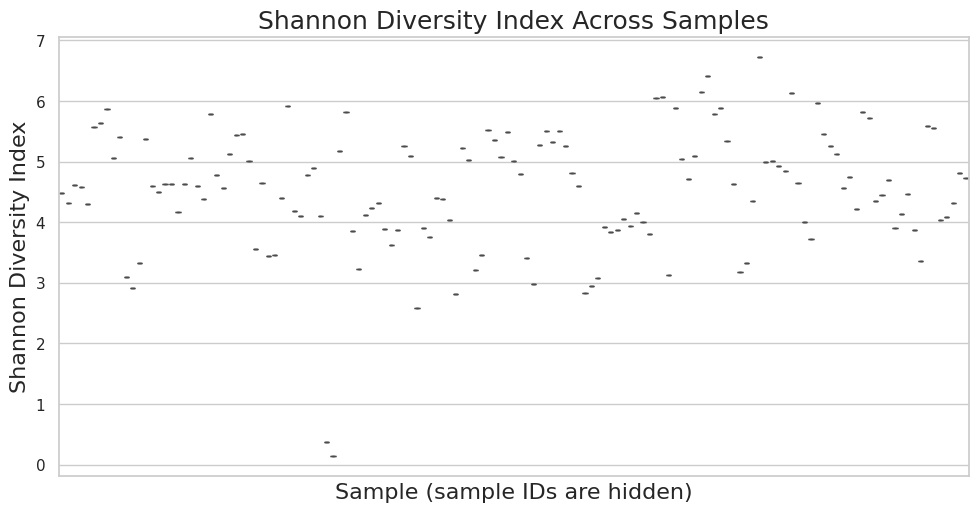

In [52]:
# path to alpha diversity data
alpha_diversity_path = DADA2_RESULT_DIR /  "diversity"
# load data
df_alpha = pd.read_csv(alpha_diversity_path / "alpha-diversity.tsv", sep="\t")
# Display the alpha diversity dataframe
df_alpha.head()
df_alpha.rename(columns={"Unnamed: 0": "sample_id"}, inplace=True)
df_alpha.head()

# Plot alpha diversity
plt.figure(figsize=(10, 6))
sns.boxplot(x="sample_id", y="shannon_entropy", data=df_alpha)
plt.title("Shannon Diversity Index Across Samples", fontsize=18)
plt.xlabel("Sample (sample IDs are hidden)", fontsize=16)
plt.ylabel("Shannon Diversity Index", fontsize=16)
plt.xticks(rotation=90) # Rotate x-axis labels if needed
plt.tight_layout()
plt.xticks([]) # hide sample names

## Beta diversity

A similar approach is apploed to beta diversity measured through Bray Curtis PCoA.

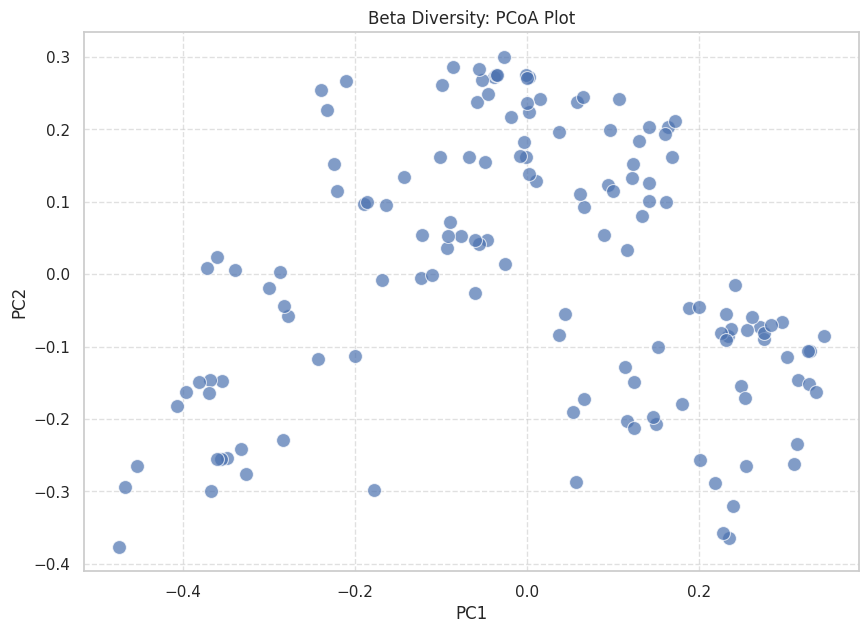

In [53]:


# path to beta diversity data
beta_diversity_path = DADA2_RESULT_DIR / "diversity"
# load data

# Step 1: Read the file and find the 'Site' section
with open(beta_diversity_path / 'ordination.txt', 'r') as f:
    content = f.read()

# We split the file to find the 'Site' section where the coordinates live
site_section = content.split('Site')[1].split('\n\n')[0]

# Step 2: Load into Pandas (skipping the first line which is 'Site [rows] [cols]')
df_coords = pd.read_csv(io.StringIO(site_section), sep='\t', skiprows=1, header=None)
df_coords.head()

# Step 3: Rename columns (The first column is Sample ID, then PC1, PC2...)
df_coords.columns = ['SampleID'] + [f'PC{i}' for i in range(1, len(df_coords.columns))]
df_coords.head()
# Plotting the PCoA results

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_coords, x='PC1', y='PC2', s=100, alpha=0.7)

plt.title('Beta Diversity: PCoA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Taxonomic analysis PICRUST2 (depricated)

Since PICRUST2 data is coming from QIIME2, it also contains data from taxonomic composition.

In [56]:
# Load data

ec = pd.read_csv(ec_file, sep="\t")
#ko = pd.read_csv(ko_file, sep="\t")
tax = pd.read_csv(taxa_file, sep="\t")


print("EC columns:", ec.columns.tolist())
#print("KO columns:", ko.columns.tolist())
print("TAX columns:", tax.columns.tolist())
#print("Pathways unstrat columns:", pathways_unstrat.columns.tolist())
#print("Pathways contrib columns:", pathways_contrib.columns.tolist())

EC columns: ['sample', 'function', 'taxon', 'taxon_abun', 'taxon_rel_abun', 'genome_function_count', 'taxon_function_abun', 'taxon_rel_function_abun', 'norm_taxon_function_contrib']
TAX columns: ['Feature ID', 'Taxon', 'Confidence']


In [57]:
# Check number of unique samples in EC data
ec['sample'].nunique()

165

In [60]:
# Standardize taxon_id column in tax, ec, and ko dataframes

def standardize_taxon_column(df):
    rename_map = {
        "Taxon": "taxon_id",
        "taxon": "taxon_id",
        "Feature ID": "taxon_id",
        "feature_id": "taxon_id"
    }

    for col, new_col in rename_map.items():
        if col in df.columns:
            df = df.rename(columns={col: new_col})

    if "taxon_id" not in df.columns:
        raise ValueError(f"No taxon column found in columns: {df.columns}")

    return df

In [61]:
tax = tax.rename(columns={
    "Feature ID": "taxon_id",
    "Taxon": "Taxon_label"
})

ec = standardize_taxon_column(ec)
#ko = standardize_taxon_column(ko)

In [63]:
# Fast mode
TEST_MODE = False

# In test mode keep only 2 samples

if TEST_MODE:
    print("\nRunning in TEST MODE (2 samples)...")

    selected_samples = ec["sample"].drop_duplicates().head(2).tolist()
    print("Selected samples:", selected_samples)

    ec = ec[ec["sample"].isin(selected_samples)]
    #ko = ko[ko["sample"].isin(selected_samples)]

    print("Filtered EC shape:", ec.shape)
    #print("Filtered KO shape:", ko.shape)


## Merge taxa and EC/KO

In [64]:
# fix column names

tax = tax.rename(columns={
    "Feature ID": "taxon_id",
    "Taxon": "Taxon_label"
})

# Ensure same naming in EC/KO
ec = ec.rename(columns={"taxon": "taxon_id"})

# merge taxonomy with EC and KO data
print("\nMerging taxonomy...")

ec_tax = ec.merge(tax, on="taxon_id", how="left")

print("EC_tax shape:", ec_tax.shape)


ec_tax = ec_tax.rename(columns={
    'taxon': 'taxon_id',
    'Taxon': 'Taxon_label'
})



Merging taxonomy...
EC_tax shape: (11095441, 11)


In [ ]:
ec_tax.head()

## Taxonomy parsing (GENUS level)

Extract the name of the taxon class (genus in this case g_) from the full taxonomic string

In [65]:
# Taxonomy parsing (GENUS level)
def extract_tax_level(tax_lineage, prefix):
    if pd.isna(tax_lineage):
        return "Unclassified"

    for level in str(tax_lineage).split(";"):
        level = level.strip()  # remove spaces

        if level.startswith(prefix):
            value = level.replace(prefix, "").strip()

            if value == "" or value == "_":
                return "Unclassified"

            return value

    return "Unclassified"



ec_tax["Taxon_class"] = ec_tax["Taxon_label"].apply(lambda x: extract_tax_level(x, "g__"))


In [66]:
ec_tax0 = ec_tax.copy()

In [67]:
print(ec_tax0['sample'].nunique())
ec_tax0.head()

165


,sample,function,taxon_id,taxon_abun,taxon_rel_abun,genome_function_count,taxon_function_abun,taxon_rel_function_abun,norm_taxon_function_contrib,Taxon_label,Confidence,Taxon_class
0,206534,4.1.1.1,38eaa8f3d127290bf06b9a82171c37c0,49.00,0.177874,1.0,49.00,0.177874,0.025912,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.898227,Proteus
1,206534,4.1.1.1,b4bb370a59f2637d406ccc0f5a1b2a1e,1842.00,6.686613,1.0,1842.00,6.686613,0.974088,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.999243,Morganella
2,206534,1.5.1.41,38eaa8f3d127290bf06b9a82171c37c0,49.00,0.177874,1.0,49.00,0.177874,0.022896,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.898227,Proteus
3,206534,1.5.1.41,9c4d4b6d306824a963a9ea03bf5ed140,25.71,0.093329,1.0,25.71,0.093329,0.012013,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.936230,Escherichia-Shigella
4,206534,1.5.1.41,b4bb370a59f2637d406ccc0f5a1b2a1e,1842.00,6.686613,1.0,1842.00,6.686613,0.860691,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.999243,Morganella


In [68]:
# Prepare data for plotting
df = ec_tax0.groupby(["sample","Taxon_class"])["taxon_abun"].sum().reset_index()
df["rel"] = df.groupby("sample")["taxon_abun"].transform(lambda x: x / x.sum())
df_pivot = df.pivot_table(
    index="sample",
    columns="Taxon_class",
    values="rel",
    fill_value=0
)

In [69]:
# Check pivot shape
df_rel = df_pivot.div(df_pivot.sum(axis=1), axis=0)
df_rel

# select top genera
top_n = 10
top_taxa = df_rel.mean(axis=0).sort_values(ascending=False).head(top_n).index

df_top = df_rel[top_taxa]

# Compute "Other"
other = df_rel.drop(columns=top_taxa).sum(axis=1)
df_top["Other"] = other


/tmp/ipykernel_41623/4194537349.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["Other"] = other


## Barplot taxa PICRUST2

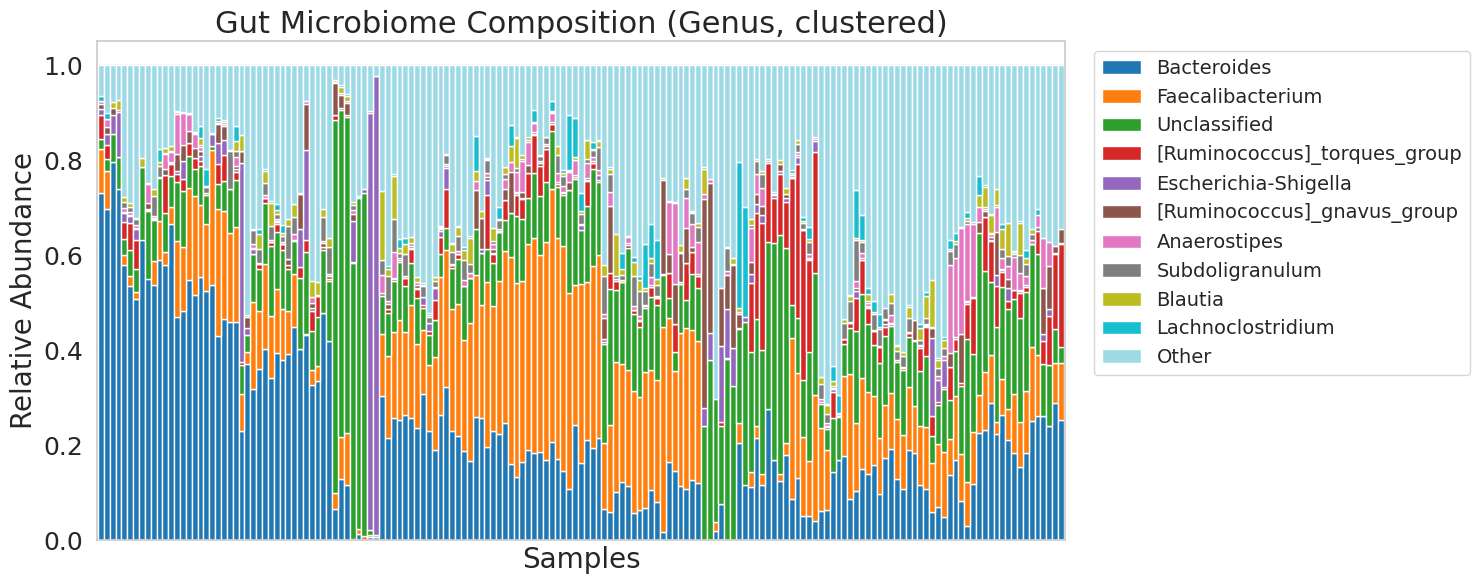

In [70]:
# Perform clustering on the samples
Z = linkage(df_rel, method='ward')
# Get the order of samples from the dendrogram
idx = dendrogram(Z, no_plot=True)['leaves']

# Reorder your plotting dataframe
df_plot_sorted = df_top.iloc[idx]

colors = plt.cm.tab20(np.linspace(0, 1, df_plot_sorted.shape[1]))

ax = df_plot_sorted.plot(
    kind='bar',
    stacked=True,
    width=1.0,
    figsize=(15, 6),
    color=colors
)

plt.ylabel("Relative Abundance", fontsize=16)
plt.xlabel("Samples", fontsize=20)
plt.ylabel("Relative Abundance", fontsize=20)
plt.title("Gut Microbiome Composition (Genus, clustered)", fontsize=22)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=18)
plt.xticks([])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)

plt.tight_layout()
plt.savefig(FIG_PATH / "genus_composition_picrust2.png", dpi=300, bbox_inches='tight')
plt.show()

# Print sample numbers of interest

In [78]:
interesting_samples = df_plot_sorted[df_plot_sorted['Anaerostipes'] > 0.1].index
print(interesting_samples.tolist())

[206710, 206711, 215074, 215077, 219644, 206629, 206630, 206757]


# Functional analysis with data from PICRUST2 (pathways)

In [79]:
# Load data
pathways_unstrat = pd.read_csv(pathways_unstrat_file, sep="\t", index_col=0).T # total abundance per pathway (do not know which taxa contributed)
print("Number of pathways:", pathways_unstrat.shape[1]) # check

#pathways_contrib = pd.read_csv(pathways_contrib_file, sep="\t", index_col=0).T # contribution of each taxon to each pathway

Number of pathways: 527


In [80]:
pathways_unstrat.head()

pathway,12DICHLORETHDEG-PWY,14DICHLORBENZDEG-PWY,1CMET2-PWY,3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,4-HYDROXYMANDELATE-DEGRADATION-PWY,AEROBACTINSYN-PWY,ALLANTOINDEG-PWY,ANAEROFRUCAT-PWY,ANAGLYCOLYSIS-PWY,ARG+POLYAMINE-SYN,...,SULFATE-CYS-PWY,THISYNARA-PWY,THRESYN-PWY,TOLUENE-DEG-3-OH-PWY,TRNA-CHARGING-PWY,TYRFUMCAT-PWY,UDPNAGSYN-PWY,URDEGR-PWY,URSIN-PWY,VALSYN-PWY
206534,0.0,0.000000,27461.206564,0.000000,9.52748,0.000000,421.124035,19908.062267,33105.510477,3416.362716,...,18873.069125,30267.599506,34698.126314,0.0,29103.536714,9.237229,12878.300080,603.287527,37.781258,31553.294549
206536,0.0,0.666466,22344.357815,0.000000,0.00000,0.000000,410.413193,15331.831854,26977.011864,2974.731982,...,14076.040030,25151.142595,28269.798327,0.0,23808.731743,13.528628,10278.518845,498.738570,6.639511,25312.580981
206538,0.0,0.000000,11019.773428,0.000000,0.00000,0.000000,208.312922,8038.926790,13276.939490,2079.922496,...,7746.281919,12006.502696,13972.967464,0.0,11828.114171,0.000000,5334.724824,330.778585,0.000000,12706.024503
206547,0.0,5.330511,16994.620953,202.253027,0.00000,7.343051,2458.902910,15399.597113,18629.722544,8460.418818,...,9149.150516,16431.586677,19332.311311,0.0,18719.698358,95.073134,12452.926239,2291.761739,252.755246,23153.091726
206548,0.0,0.000000,7844.833435,199.478133,0.00000,10.000000,1153.178102,6412.497805,7838.909784,3409.837507,...,4551.786546,7051.870251,8388.328047,0.0,8193.043113,0.000000,4973.906836,1193.786351,197.634959,10060.876432


In [81]:
# Normalize to relative abundance and log-transform
pathways_rel = pathways_unstrat.div(pathways_unstrat.sum(axis=1), axis=0)   # per sample
#pathways_log = np.log10(pathways_rel + 1e-6)


## Pathways data prep

In [82]:
# select top pathways
pathways_rel = pathways_unstrat.div(pathways_unstrat.sum(axis=1), axis=0) # relative abundance per sample using unstratified data (total abundance per pathway, do not know which taxa contributed)

## Functional composition

There are many pathways and we cannon plot everything at the same time. Thus, we will plot the core pathways (pathways maintained in most of the samples) and the accesory pathways, separately.

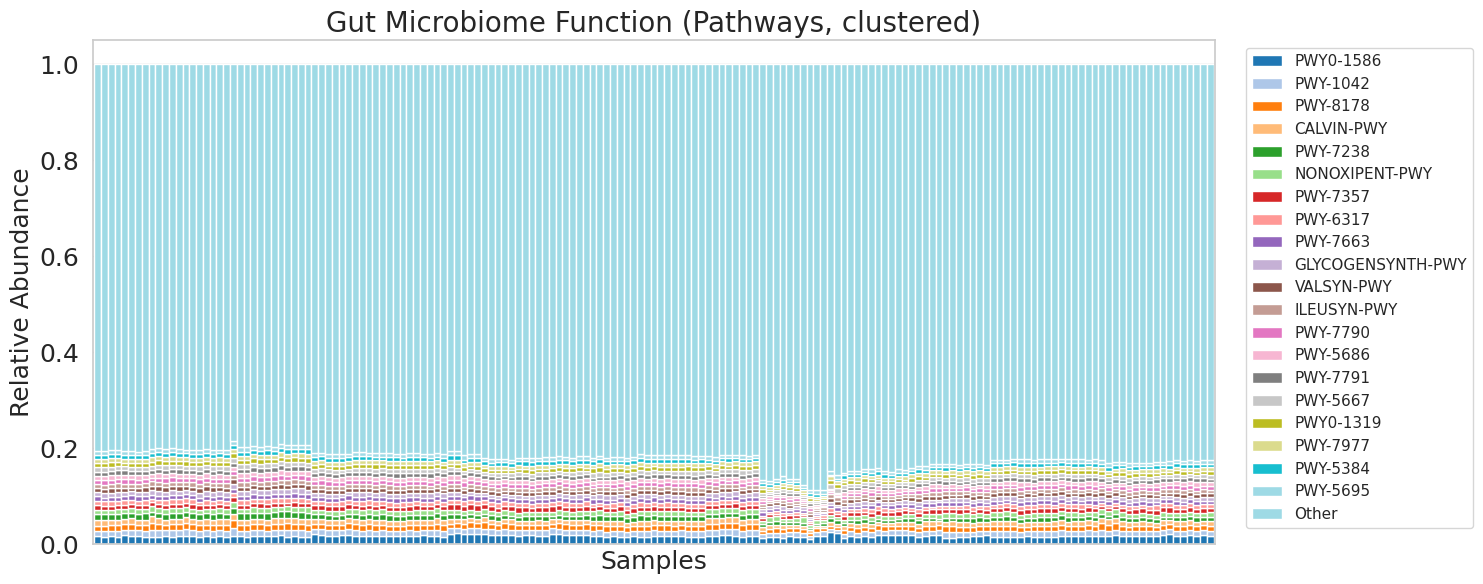

In [83]:
top_n = 20 # number of top pathways to select

top_pathways = pathways_rel.mean(axis=0).sort_values(ascending=False).head(top_n).index #select top pathways based on mean relative abundance

df_plot = pathways_rel[top_pathways].copy()
df_plot["Other"] = pathways_rel.drop(columns=top_pathways).sum(axis=1)

Z = linkage(df_plot, method='ward')
idx = dendrogram(Z, no_plot=True)['leaves']

df_plot_sorted = df_plot.iloc[idx]

colors = plt.cm.tab20(np.linspace(0, 1, df_plot_sorted.shape[1]))

ax = df_plot_sorted.plot(
    kind='bar',
    stacked=True,
    width=1.0,
    figsize=(15, 6),
    color=colors
)

plt.xlabel("Samples", fontsize=18)
plt.ylabel("Relative Abundance", fontsize=18)
plt.title("Gut Microbiome Function (Pathways, clustered)", fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=18)
plt.xticks([])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIG_PATH / "pathway_composition_clustered.png", dpi=300, bbox_inches='tight')
plt.show()

## Functional variability

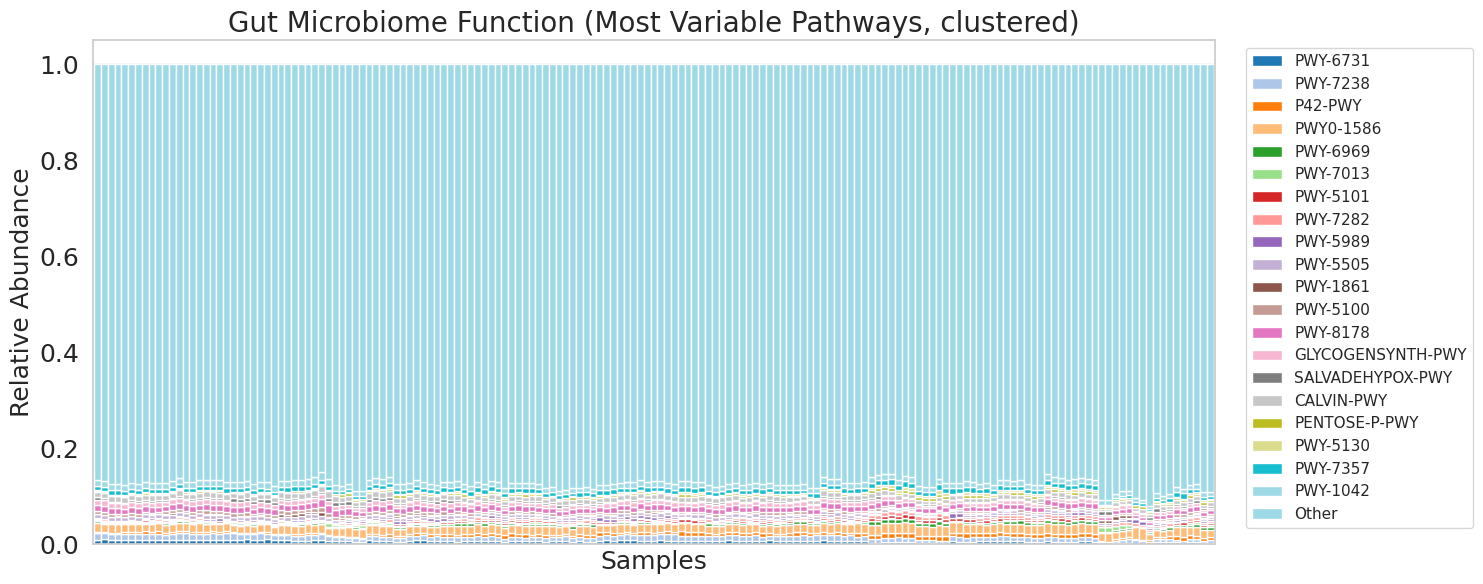

In [84]:
# Select most variable pathways
top_n = 20

top_pathways = pathways_rel.var(axis=0) \
    .sort_values(ascending=False) \
    .head(top_n).index

# Build plotting table
df_plot = pathways_rel[top_pathways].copy()

# Add "Other" (computed in linear space, correct)
df_plot["Other"] = pathways_rel.drop(columns=top_pathways).sum(axis=1)

# Cluster samples
Z = linkage(df_plot.drop(columns=["Other"]), method='ward')

idx = dendrogram(Z, no_plot=True)['leaves']

df_plot_sorted = df_plot.iloc[idx]

# Plot
colors = plt.cm.tab20(np.linspace(0, 1, df_plot_sorted.shape[1]))

ax = df_plot_sorted.plot(
    kind='bar',
    stacked=True,
    width=1.0,
    figsize=(15, 6),
    color=colors
)

plt.xlabel("Samples", fontsize=18)
plt.ylabel("Relative Abundance", fontsize=18)
plt.title("Gut Microbiome Function (Most Variable Pathways, clustered)", fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=18)  # clean for presentation
plt.xticks([])  # clean for presentation
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIG_PATH / "pathway_variable_clustered.png", dpi=300, bbox_inches='tight')
plt.show()

## Functional sparsity

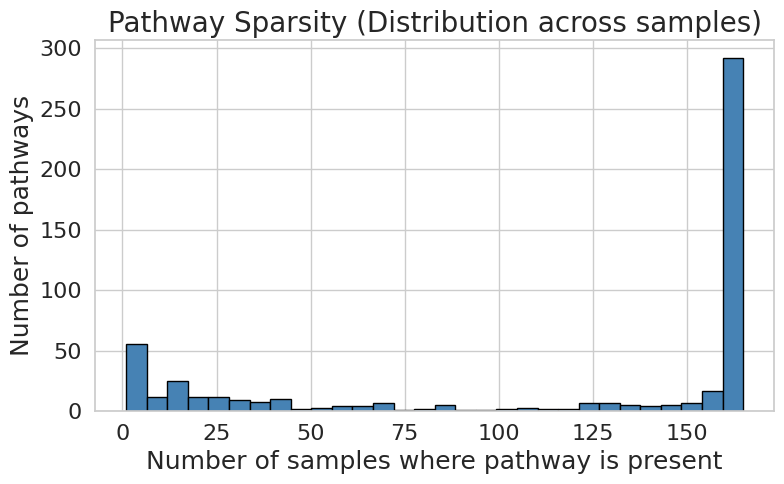

In [85]:
# number of samples where each pathway is present
sample_counts = (pathways_unstrat > 0).sum(axis=0)

plt.figure(figsize=(8,5))
plt.hist(sample_counts, bins=30, color="steelblue", edgecolor="black")

plt.xlabel("Number of samples where pathway is present", fontsize=18)
plt.ylabel("Number of pathways", fontsize=18)
plt.title("Pathway Sparsity (Distribution across samples)", fontsize=20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.tight_layout()
plt.savefig(FIG_PATH / "pathway_sparsity.png", dpi=300, bbox_inches='tight')
plt.show()

## Pathway prevalence

In [86]:
# prevalence per pathway
prevalence = (pathways_rel > 0).sum(axis=0) / pathways_rel.shape[0]

# define core and accessory
core_pathways = prevalence[prevalence > 0.99].index # Very strict definition!
accessory_pathways = pathways_rel.columns.difference(core_pathways)

# print results correctly
print("Number of pathways prevalent in 99% of samples:", len(core_pathways))
print("Number of accessory pathways:", len(accessory_pathways))

Number of pathways prevalent in 99% of samples: 267
Number of accessory pathways: 260


## Core pathways relative abundance

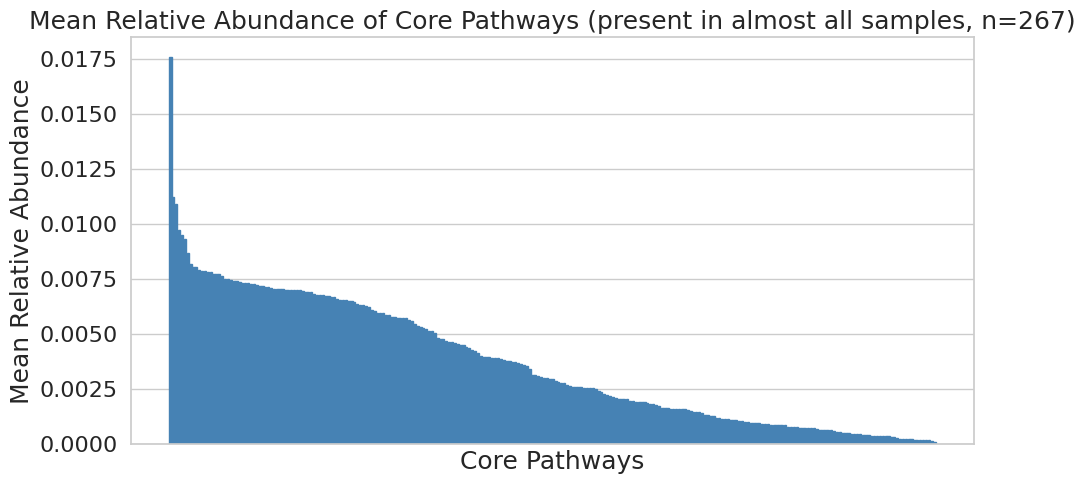

In [87]:

# prevalence
prevalence = (pathways_rel > 0).sum(axis=0) / pathways_rel.shape[0]

# core
core_pathways = prevalence[prevalence > 0.99].index
core_abundance = pathways_rel[core_pathways]

core_mean = core_abundance.mean().sort_values(ascending=False) # mean abundance of core pathways across samples

# ---- plot ----
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    core_mean.index,
    core_mean.values,
    color="steelblue",
    edgecolor="steelblue",
    width=0.8
)


plt.xlabel("Core Pathways", fontsize=18)
plt.ylabel("Mean Relative Abundance", fontsize=18)
plt.title(f"Mean Relative Abundance of Core Pathways (present in almost all samples, n={len(core_pathways)})", fontsize=18)
plt.yticks(fontsize=16)
plt.xticks([], fontsize=16)
plt.tight_layout()
plt.savefig(FIG_PATH / "core_pathways_mean_abundance.png", dpi=300, bbox_inches='tight')
plt.show()

# Prevalence vs relative abundance

Challenge: the most abundant pathway could be outside the "Core pathways" group. We will decouple prevalence from relative abundance through a scatterplot. This plot separates functional stability (prevalence) from functional activity (abundance).

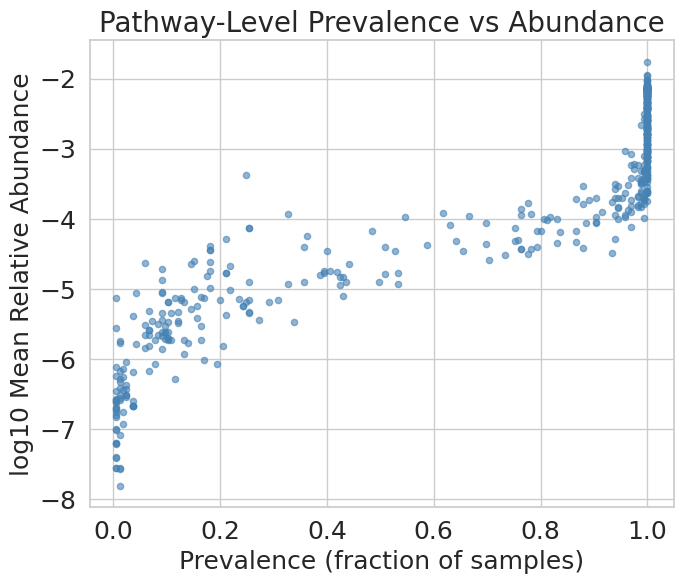

In [88]:
# pathway-level prevalence
prevalence = (pathways_rel > 0).sum(axis=0) / pathways_rel.shape[0]

# pathway-level mean abundance
mean_abundance = pathways_rel.mean(axis=0)

df_plot = pd.DataFrame({
    "prevalence": prevalence,
    "mean_abundance": mean_abundance
})

# log transform (recommended due to skewness)
df_plot["log_mean_abundance"] = np.log10(df_plot["mean_abundance"] + 1e-10)

plt.figure(figsize=(7,6))

plt.scatter(
    df_plot["prevalence"],
    df_plot["log_mean_abundance"],
    alpha=0.6,
    s=20,
    color="steelblue"
)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Prevalence (fraction of samples)", fontsize=18)
plt.ylabel("log10 Mean Relative Abundance", fontsize=18)
plt.title("Pathway-Level Prevalence vs Abundance", fontsize=20)
plt.savefig(FIG_PATH / "prevalence_vs_abundance.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Overall, this scatterplot shows that higher prevalence tends to be associated with higher mean abundance, which is consistent with the concept of core pathways defined by high ubiquity across samples.

# Save tables

Save the tables from picrust2 for downstream analysis

In [89]:
#Load picrust2 tables

# Pathways (functional profiles)
#pathways = pd.read_csv(pathways_rel, sep="\t", index_col=0)
#print(f"Pathways table shape: {pathways.shape}")
# Pathway contributions
#pathways_contrib = pd.read_csv(pathways_contrib_file, sep="\t", index_col=0)
#print(f"Pathway contributions table shape: {pathways_contrib.shape}")

pathways_rel.to_csv(TABLE_PATH / "pathways_unstrat_relative.csv", index=True)
#pathways_contrib.to_csv(TABLE_PATH / "pathways_contrib.csv")

print("All PICRUSt2 tables saved to 'results/' folder.")

All PICRUSt2 tables saved to 'results/' folder.
